# CIND 820 Capstone: Post-Default Recovery Optimization
**Author:** Syed Muzammil Iqbal  
**Dataset:** LendingClub (2007-2018) | Filtered for `loan_status == 'Charged Off'`

## Phase 1: Data Analysis
Data Loading and Exploratory Data Analysis (EDA):
The objective of this initial phase is to isolate the target population (defaulted borrowers) and validate the core data constraints outlined in the project's literature review.

In unsecured consumer lending, recovery distributions are rarely normal. They suffer from **"zero-inflation"**—meaning a massive proportion of defaulted borrowers will never pay back a single cent. The code below extracts the ~268,000 "Charged Off" accounts, calculates the exact percentage of zero-dollar recoveries, and visualizes this highly right-skewed distribution. This skewness serves as the primary justification for exploring non-linear modeling techniques later in this notebook.

Loading data...
Total Charged Off loans to analyze: 268559
Percentage of loans with $0 Gross Recovery: 31.23%


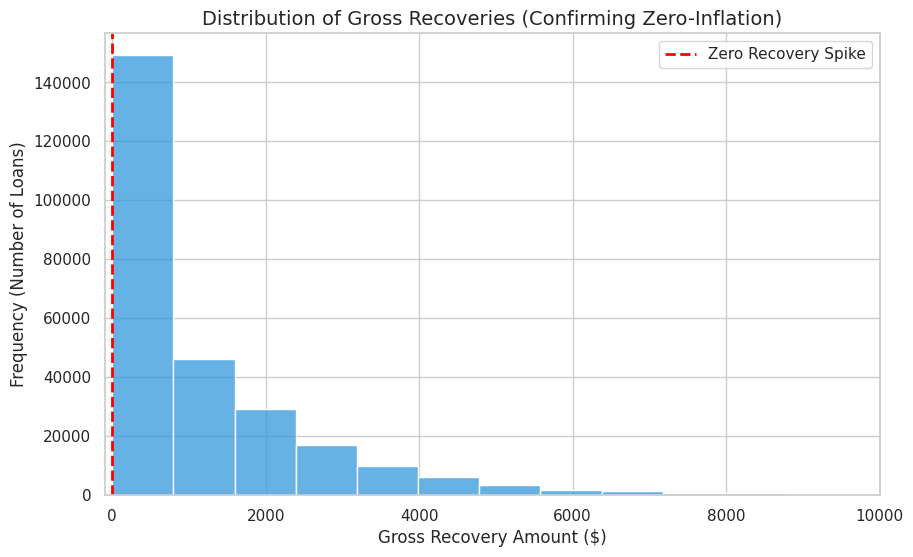

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
file_path = '/content/drive/MyDrive/Capstone/recovery_analysis_data.csv'
print("Loading data...")
df_raw = pd.read_csv(file_path, low_memory=False)

# 2. Filter for Post-Default Population
# We only care about loans that are 'Charged Off'
df = df_raw[df_raw['loan_status'] == 'Charged Off'].copy()
print(f"Total Charged Off loans to analyze: {df.shape[0]}")

# 3. Validate the "Zero-Inflation" Constraint
# Let's calculate the exact percentage of $0 recoveries
zero_recovery_count = (df['recoveries'] == 0).sum()
total_count = len(df)
zero_recovery_pct = (zero_recovery_count / total_count) * 100

print(f"Percentage of loans with $0 Gross Recovery: {zero_recovery_pct:.2f}%")

# 4. Visualize the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['recoveries'], bins=50, kde=False, color='#3498db')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Recovery Spike')
plt.title('Distribution of Gross Recoveries (Confirming Zero-Inflation)', fontsize=14)
plt.xlabel('Gross Recovery Amount ($)', fontsize=12)
plt.ylabel('Frequency (Number of Loans)', fontsize=12)
plt.xlim(-100, 10000) # Zooming in to see the spike clearly
plt.legend()
plt.show()

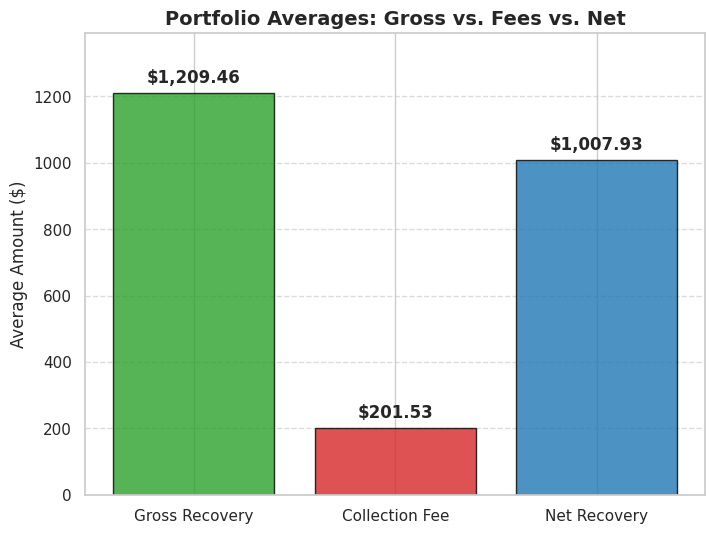

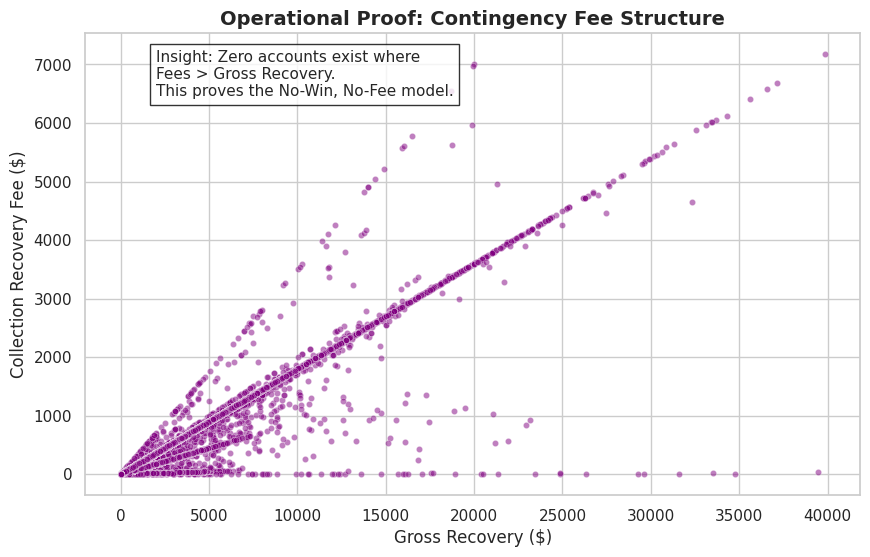

In [18]:
# ==========================================
# PHASE 1 VISUAL: AVERAGE RECOVERY VS FEES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the exact averages directly from the dataframe
avg_gross = df['recoveries'].mean()
avg_fee = df['collection_recovery_fee'].mean()
avg_net = (df['recoveries'] - df['collection_recovery_fee']).mean() # Fixed this line!

# Set up the data for the chart
categories = ['Gross Recovery', 'Collection Fee', 'Net Recovery']
averages = [avg_gross, avg_fee, avg_net]
colors = ['#2ca02c', '#d62728', '#1f77b4']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, averages, color=colors, alpha=0.8, edgecolor='black')

# Add the exact dollar amounts on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20,
             f'${yval:,.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Portfolio Averages: Gross vs. Fees vs. Net', fontsize=14, fontweight='bold')
plt.ylabel('Average Amount ($)', fontsize=12)
plt.ylim(0, max(averages) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Scatter plot of Gross Recovery vs Collection Fee
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['recoveries'], y=df['collection_recovery_fee'],
                alpha=0.5, color='purple', s=20)

# Title and Labels
plt.title('Operational Proof: Contingency Fee Structure', fontsize=14, fontweight='bold')
plt.xlabel('Gross Recovery ($)', fontsize=12)
plt.ylabel('Collection Recovery Fee ($)', fontsize=12)

# Adding a reference text box to explain the insight directly on the chart
plt.text(df['recoveries'].max()*0.05, df['collection_recovery_fee'].max()*0.9,
         "Insight: Zero accounts exist where\nFees > Gross Recovery.\nThis proves the No-Win, No-Fee model.",
         fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.show()

## Phase 2: Data Preparation
Feature Engineering & Target Variable Construction:

Traditional Loss Given Default (LGD) models predict *gross* recovery. However, from an operational perspective, third-party collection efforts incur significant fees. To optimize for actual profitability, we engineer a new target variable: **`Net_Recovery`** (`recoveries` - `collection_recovery_fee`).

**Handling Structural Missingness:**
The variable `mths_since_last_delinq` contains a high volume of missing values. In the context of LendingClub data, a missing value here is not a random error; it indicates that the borrower has *never* been delinquent before. We impute these values with `-1` to preserve this clean historical signal for the model.

**Business Insight on Collection Fees:**
Exploratory data analysis confirms there are 0 accounts with a negative Net Recovery. This mathematically proves that LendingClub utilizes a strict contingency-fee model for external collections (e.g., the agency only takes a percentage of the amount recovered, meaning out-of-pocket costs never exceed the collected amount). Thus, our optimization problem focuses on *opportunity cost* and *time value of money* rather than direct financial loss from collection fees.

Starting Data Preparation...
Number of accounts with Negative Net Recovery (Fees > Recoveries): 0
Filled 130742 missing values in 'mths_since_last_delinq' with -1.

--- Summary Statistics for Net_Recovery ---
count    268559.000000
mean       1007.930683
std        1533.298144
min           0.000000
25%           0.000000
50%         493.976200
75%        1438.103700
max       39397.805600
Name: Net_Recovery, dtype: float64


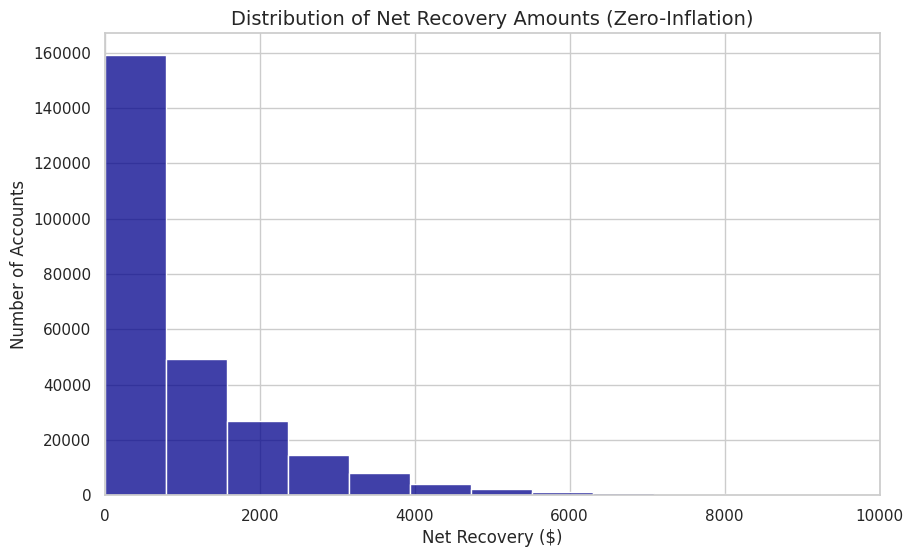

In [20]:
# ==========================================
# PHASE 2: DATA PREPARATION
# ==========================================

print("Starting Data Preparation...")

# 1. Create the 'Net_Recovery' Target Variable
# Gross recoveries minus the fees paid to collection agencies
df['Net_Recovery'] = df['recoveries'] - df['collection_recovery_fee']

# Let's see how many accounts actually lost money during the collection process
negative_net = (df['Net_Recovery'] < 0).sum()
print(f"Number of accounts with Negative Net Recovery (Fees > Recoveries): {negative_net}")

# 2. Handle Structural Missingness in 'mths_since_last_delinq'
# In LendingClub data, a missing value here means the borrower was NEVER delinquent before.
# We fill NaNs with -1 to tell the model that "no history of delinquency" is a specific, clean state.
missing_delinq_before = df['mths_since_last_delinq'].isna().sum()
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(-1)
print(f"Filled {missing_delinq_before} missing values in 'mths_since_last_delinq' with -1.")

# 3. Prevent Data Leakage
# We must drop variables that the model wouldn't know at the exact moment the loan defaults.
# If we keep 'recoveries' or 'collection_recovery_fee', the model will "cheat" to predict Net_Recovery.
leakage_cols = [
    'recoveries', 'collection_recovery_fee', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt'
]

# We will drop these later when we build the model training set,
# but for now, let's look at the summary of our new target variable.

print("\n--- Summary Statistics for Net_Recovery ---")
print(df['Net_Recovery'].describe())

# ==========================================
# PHASE 2 VISUAL: ZERO-INFLATION HISTOGRAM
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Net_Recovery'], bins=50, kde=False, color='darkblue')
plt.title('Distribution of Net Recovery Amounts (Zero-Inflation)', fontsize=14)
plt.xlabel('Net Recovery ($)', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)
plt.xlim(0, 10000)
plt.show()

## Phase 3: Model Evaluation
Feature Selection, Preprocessing, and Encoding:

To prepare the dataset for machine learning algorithms, we must transform all features into a clean, numeric format. This step fulfills the data preparation requirements of the CRISP-DM lifecycle.

**Preprocessing Steps:**
1. **Feature Selection:** We isolate predictor variables available at the exact moment of default (e.g., `loan_amnt`, `dti`, `int_rate`, `grade`) and drop future data (like `total_pymnt`) to prevent data leakage.
2. **Data Cleaning:** String variables like `term` ("36 months") and `int_rate` ("15.5%") are stripped of text and converted to floats.
3. **Missing Values:** Missing financial indicators (like `dti`) are imputed using the median to avoid outlier distortion.
4. **Categorical Encoding:** The `grade` feature is ordinally encoded (A=1 through G=7) to allow the algorithms to understand the hierarchical risk levels assigned at loan origination.

In [21]:
# ==========================================
# PHASE 3: Model Evaluation - FEATURE SELECTION & PREPROCESSING
# ==========================================

print("Starting Feature Selection & Preprocessing...")

# 1. Select Core Features (Predictors)
# We choose variables available at the time of default that influence recovery.
features = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'dti', 'mths_since_last_delinq'
]

# Create our working dataset with X (predictors) and y (target)
X = df[features].copy()
y = df['Net_Recovery'].copy()

# 2. Clean Text/String Columns into Numeric
# The 'term' column usually looks like " 36 months". We just want the number.
if X['term'].dtype == 'O': # 'O' stands for Object/String
    X['term'] = X['term'].str.extract(r'(\d+)').astype(float)

# The 'int_rate' column is sometimes a string with a '%' sign. Let's fix that if needed.
if X['int_rate'].dtype == 'O':
    X['int_rate'] = X['int_rate'].astype(str).str.replace('%', '').astype(float)

# 3. Handle Remaining Missing Values
# For core financial metrics like 'dti', we'll fill missing values with the median.
X['dti'] = X['dti'].fillna(X['dti'].median())

# 4. Encode Categorical Variables
# 'grade' is an ordinal variable (A is better than B, etc.).
# We will map it to numbers: A=1, B=2, C=3, D=4, E=5, F=6, G=7.
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
X['grade_encoded'] = X['grade'].map(grade_mapping)

# Drop the original text 'grade' column now that we have the encoded one
X = X.drop('grade', axis=1)

# Let's check our final processed features
print("\n--- Final Preprocessed Features (First 5 Rows) ---")
print(X.head())
print(f"\nShape of X (Predictors): {X.shape}")
print(f"Shape of y (Target): {y.shape}")
print("\nCheck for any remaining missing values in X:")
print(X.isna().sum())

Starting Feature Selection & Preprocessing...

--- Final Preprocessed Features (First 5 Rows) ---
   loan_amnt  term  int_rate  installment    dti  mths_since_last_delinq  \
0    18000.0  60.0     19.48       471.70   9.39                    -1.0   
1     4225.0  36.0     14.85       146.16  15.22                    18.0   
2    16000.0  36.0     12.88       538.18  18.96                    33.0   
3    24250.0  60.0     24.24       701.01  20.84                    -1.0   
4    25000.0  60.0     13.99       581.58  34.53                    -1.0   

   grade_encoded  
0              5  
1              3  
2              3  
3              6  
4              3  

Shape of X (Predictors): (268559, 7)
Shape of y (Target): (268559,)

Check for any remaining missing values in X:
loan_amnt                 0
term                      0
int_rate                  0
installment               0
dti                       0
mths_since_last_delinq    0
grade_encoded             0
dtype: int64


## Phase 4: Predictive Modeling (Baseline vs. Champion)

In this phase, we conduct a dual-model analysis to predict the continuous `Net_Recovery` dollar amount.

1. **Baseline Model (Ordinary Least Squares Linear Regression):** Used to establish a performance floor. We hypothesize that OLS will struggle to capture the complex, zero-inflated nature of debt recovery.
2. **Champion Model (Random Forest Regressor):** A non-linear, tree-based ensemble method selected to handle the right-skewed distribution and capture "cliff effects" in borrower behavior.

**Evaluation Metrics:**
Models are evaluated on unseen testing data (a 70/30 split) using **Root Mean Squared Error (RMSE)** to measure average dollar deviation, and **R-Squared ($R^2$)** to measure explained variance. While $R^2$ values typically appear low when predicting volatile human financial behavior, our goal is to capture actionable operational signals rather than perfect foresight.

Starting Predictive Modeling...

Training data shape: X=(187991, 7), y=(187991,)
Testing data shape: X=(80568, 7), y=(80568,)

Training Baseline Model (Linear Regression)...
--- Baseline Model Results ---
RMSE: $1381.44
R-Squared: 0.1710

Training Champion Model (Random Forest)... This might take a minute or two!
--- Champion Model Results ---
RMSE: $1380.30
R-Squared: 0.1723

--- Final Verdict ---
Random Forest outperformed Linear Regression, as hypothesized!


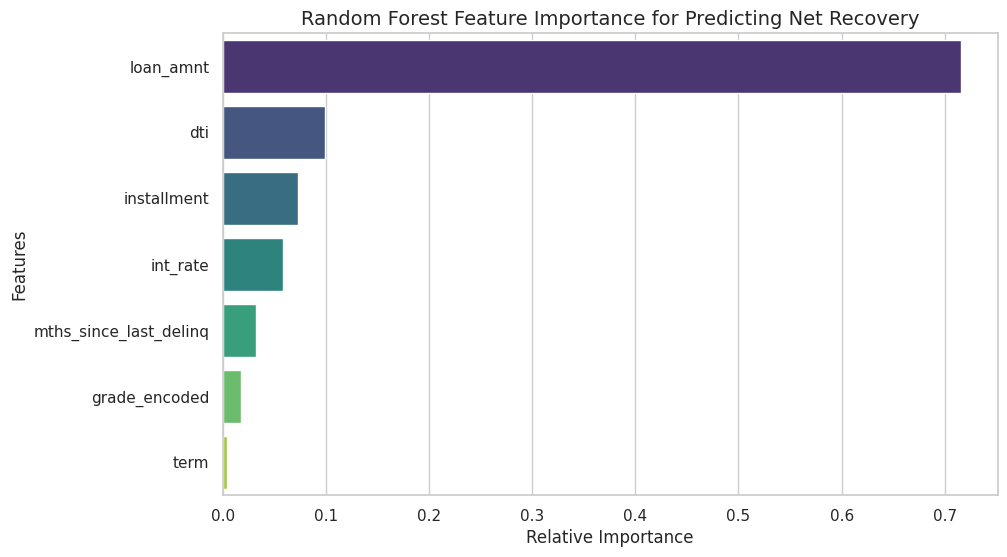

In [22]:
# ==========================================
# PHASE 4: PREDICTIVE MODELING (DUAL ANALYSIS)
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Starting Predictive Modeling...\n")

# 1. Train-Test Split (70/30)
# We train on 70% of the data and test on 30% of unseen data to ensure the model doesn't just memorize the answers.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}\n")

# --- BASELINE MODEL: Linear Regression ---
print("Training Baseline Model (Linear Regression)...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Evaluate Baseline
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("--- Baseline Model Results ---")
print(f"RMSE: ${lr_rmse:.2f}")
print(f"R-Squared: {lr_r2:.4f}\n")

# --- CHAMPION MODEL: Random Forest Regressor ---
print("Training Champion Model (Random Forest)... This might take a minute or two!")
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluate Champion
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("--- Champion Model Results ---")
print(f"RMSE: ${rf_rmse:.2f}")
print(f"R-Squared: {rf_r2:.4f}\n")

# Quick Comparison
print("--- Final Verdict ---")
if rf_r2 > lr_r2:
    print("Random Forest outperformed Linear Regression, as hypothesized!")
else:
    print("Linear Regression won (this would be highly unexpected).")

# ==========================================
# PHASE 4 VISUAL: RANDOM FOREST FEATURE IMPORTANCE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Extract importances from the trained model (assuming your model is named rf_model)
# and assuming your feature dataset is named X
importances = rf_model.feature_importances_

# Sort the features from most important to least important
indices = np.argsort(importances)[::-1]
sorted_features = X.columns[indices]
sorted_importances = importances[indices]

# Create the bar chart
sns.barplot(x=sorted_importances, y=sorted_features, hue=sorted_features, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance for Predicting Net Recovery', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

## Phase 5: Strategic Segmentation (K-Means Clustering)

While predicting exact recovery amounts is statistically valuable, operational debt recovery relies heavily on strategic triage. In this final phase, we shift from supervised to unsupervised learning.

Using **K-Means Clustering**, we segment the defaulted borrowers into distinct "Recovery Personas" based on their loan size, risk level (interest rate), financial strain (DTI), and actual Net Recovery. The data is standard-scaled to ensure equal distance weighting, and the model quality is evaluated using the **Silhouette Score**.

### Operational Interpretation of Centroids:
Based on the resulting cluster centroids, we can define three distinct business strategies:
* **Persona 0 ("The High-Yield Whales"):** High loan balances and moderate financial strain yielding the highest average Net Recovery (~$3,014). *Strategy: Retain internally or assign to premium contingency agencies.*

* **Persona 1 ("Small-Balance Nuisance Debt"):** Low risk, but incredibly small balances yielding minimal recovery (~$480). *Strategy: Package and sell immediately to debt buyers to avoid operational drag.*

* **Persona 2 ("The Toxic Assets"):** Subprime borrowers with severe financial strain (highest DTI) yielding very low recoveries (~$667). *Strategy: Cut losses and sell immediately; collection efforts will likely result in wasted time and zero yield.*

In [24]:
# ==========================================
# PHASE 5: STRATEGIC SEGMENTATION (CLUSTERING)
# ==========================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

print("Starting Phase 3: Strategic Segmentation (K-Means Clustering)...\n")

# 1. Select Features for Clustering
# We want to group borrowers by their loan size, financial health (DTI),
# risk level (int_rate), and the actual outcome (Net_Recovery).
cluster_data = X[['loan_amnt', 'dti', 'int_rate']].copy()
cluster_data['Net_Recovery'] = y

# 2. Scale the Data
# K-Means calculates distance, so we MUST scale the data.
# Otherwise, loan_amnt ($10,000) will overpower DTI (15.5).
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# 3. Apply K-Means Clustering
# Let's start by looking for 3 distinct "personas"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Add the cluster labels back to our dataframe so we can see who went where
cluster_data['Cluster_Persona'] = cluster_labels

# 4. Evaluate the Clusters (Silhouette Score)
# We use a random sample of 10,000 rows to calculate the score because
# running it on all 268k rows would crash Colab's memory.
np.random.seed(42)
sample_indices = np.random.choice(cluster_scaled.shape[0], size=10000, replace=False)
sil_score = silhouette_score(cluster_scaled[sample_indices], cluster_labels[sample_indices])

print(f"Silhouette Score (Model Quality): {sil_score:.4f}")
print("(Note: A score closer to 1 is better, but above 0.20 is generally acceptable for noisy human behavior data.)\n")

# 5. Interpret the Segments (Calculate Averages for each Cluster)
print("--- Cluster Centroids (Average Values per Persona) ---")
centroids = cluster_data.groupby('Cluster_Persona').mean().round(2)
print(centroids)

Starting Phase 3: Strategic Segmentation (K-Means Clustering)...

Silhouette Score (Model Quality): 0.2529
(Note: A score closer to 1 is better, but above 0.20 is generally acceptable for noisy human behavior data.)

--- Cluster Centroids (Average Values per Persona) ---
                 loan_amnt    dti  int_rate  Net_Recovery
Cluster_Persona                                          
0                 27720.13  19.28     16.73       3014.27
1                 11217.32  18.21     12.60        480.44
2                 15542.85  24.21     20.58        667.52


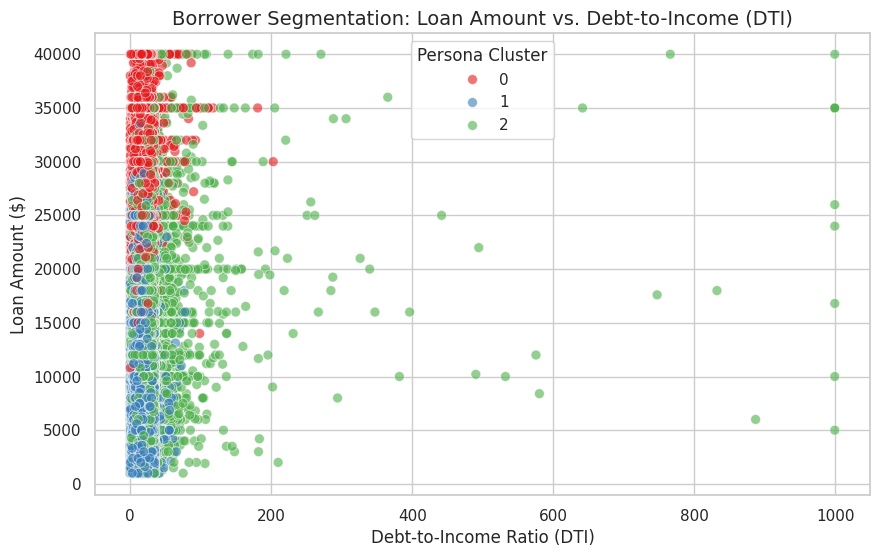

In [25]:
# ==========================================
# PHASE 5 VISUAL: BORROWER SEGMENTATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=cluster_data['dti'], y=cluster_data['loan_amnt'],
                hue=cluster_data['Cluster_Persona'], palette='Set1', s=50, alpha=0.6)

plt.title('Borrower Segmentation: Loan Amount vs. Debt-to-Income (DTI)', fontsize=14)
plt.xlabel('Debt-to-Income Ratio (DTI)', fontsize=12)
plt.ylabel('Loan Amount ($)', fontsize=12)
plt.legend(title='Persona Cluster')
plt.show()